
# NYC Yellow Taxi Data – Exploratory Data Analysis (EDA)

## Objective
The objective of this analysis is to explore New York City Yellow Taxi trip data in order to understand trip patterns, revenue behavior, payment preferences, and temporal trends.  
This EDA supports downstream SQL analysis and Power BI dashboard development.


## Dataset Overview
This dataset contains New York City Yellow Taxi trip records, including pickup and drop-off timestamps,
trip distance, fare components, payment methods, vendor information, and location identifiers.


In [15]:
import pandas as pd
import numpy as np

In [18]:
df = pd.read_parquet( 'C:\\Users\\saima\\Downloads\\yellow_tripdata_2024-01.parquet')

In [19]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.70,1.00,0.5,0.00,0.00,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.00,3.50,0.5,3.75,0.00,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.30,3.50,0.5,3.00,0.00,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.00,3.50,0.5,2.00,0.00,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.90,3.50,0.5,3.20,0.00,1.0,16.10,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2964619,2,2024-01-31 23:45:59,2024-01-31 23:54:36,NaN,3.18,NaN,None,107,263,0,15.77,0.00,0.5,2.00,0.00,1.0,21.77,NaN,NaN
2964620,1,2024-01-31 23:13:07,2024-01-31 23:27:52,NaN,4.00,NaN,None,114,236,0,18.40,1.00,0.5,2.34,0.00,1.0,25.74,NaN,NaN
2964621,2,2024-01-31 23:19:00,2024-01-31 23:38:00,NaN,3.33,NaN,None,211,25,0,19.97,0.00,0.5,0.00,0.00,1.0,23.97,NaN,NaN
2964622,2,2024-01-31 23:07:23,2024-01-31 23:25:14,NaN,3.06,NaN,None,107,13,0,23.88,0.00,0.5,5.58,0.00,1.0,33.46,NaN,NaN


## Initial Data Inspection
In this step, we examine the structure, dimensions, and data types of the dataset to understand its composition before performing data cleaning.


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [25]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='object')

# CHANGE DATA TYPE OF 4 COLUMNS

In [28]:
df['passenger_count'] = df['passenger_count'].fillna(0).astype(int) # change dataetype

In [30]:
df['RatecodeID'] = df['RatecodeID'].fillna(0).astype(int)

In [32]:
df['Airport_fee'] = (df['Airport_fee']> 0).astype(bool)

In [34]:
df['congestion_surcharge'] = df['congestion_surcharge'].astype('category')

## Missing Value Analysis
This step identifies missing values across the dataset and applies appropriate handling strategies to maintain data completeness.


In [37]:
df.isnull().sum() # df.isna().sum() both are same 

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count               0
trip_distance                 0
RatecodeID                    0
store_and_fwd_flag       140162
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     140162
Airport_fee                   0
dtype: int64

In [39]:
# FILL MISSING VALUES FOR ABOVE " COLUMNS
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('N') #FILL WITH N
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0) # FILL WITH 0

In [41]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
dtype: int64

## Duplicate Trip Identification and Handling
Taxi trip data can contain logical duplicates that inflate trip counts and revenue metrics.  
Duplicates were identified using trip-level attributes, and records were deduplicated by retaining the most recent entry per trip.


In [44]:
total_duplicates = df.duplicated().sum()
print("Total duplicate rows:", total_duplicates)


Total duplicate rows: 0


In [45]:
df.duplicated(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'passenger_count']).sum()


31108

In [46]:
df_clean = df.drop_duplicates(subset =['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'passenger_count'],keep= 'last')

#I identified approximately 31,008 duplicate taxi trip records based on core trip identifiers.
#To avoid inflating trip counts, I deduplicated the data by retaining the most recent record per trip 
#while documenting the impact on dataset size.”

## Cleaned Dataset Validation
Post-cleaning validation checks were performed to ensure data accuracy, consistency, and readiness for analysis.


In [82]:
df_clean.head()
df_clean.shape
df_clean['fare_amount'].unique()
# negative value checks

array([17.7 , 10.  , 23.3 , ..., 63.65,  1.56, 88.24])

In [84]:
  df_clean['fare_amount'].unique	

<bound method Series.unique of 0          17.70
1          10.00
2          23.30
3          10.00
4           7.90
           ...  
2964619    15.77
2964620    18.40
2964621    19.97
2964622    23.88
2964623    32.40
Name: fare_amount, Length: 2933516, dtype: float64>

## Handling Negative Fare Amounts
Negative fare values can indicate special cases such as cancellations, adjustments, or potential data entry errors. We identify and separate these records for further analysis and clean the main dataset to focus on valid trips only.


In [87]:
(df_clean['fare_amount']<0).sum() #Basic check — are there any negative values?

6547

In [89]:
df_clean[df_clean['fare_amount']<0] # to see rows wth -ve values

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
1382,2,2024-01-01 00:33:28,2024-01-01 00:33:57,2,0.00,1,N,162,162,4,-3.00,-1.0,-0.5,0.0,0.0,-1.0,-8.00,-2.5,False
2701,2,2024-01-01 00:48:30,2024-01-01 01:09:02,1,15.79,4,N,132,15,4,-91.90,-1.0,-0.5,0.0,0.0,-1.0,-96.15,0.0,False
2992,2,2024-01-01 00:32:09,2024-01-01 00:45:40,3,1.78,1,N,237,162,4,-13.50,-1.0,-0.5,0.0,0.0,-1.0,-18.50,-2.5,False
3295,2,2024-01-01 00:37:00,2024-01-01 00:46:27,1,0.85,1,N,114,107,4,-10.00,-1.0,-0.5,0.0,0.0,-1.0,-15.00,-2.5,False
3780,2,2024-01-01 00:20:29,2024-01-01 00:21:23,2,0.05,1,N,100,164,4,-3.00,-1.0,-0.5,0.0,0.0,-1.0,-8.00,-2.5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2964383,2,2024-01-31 22:07:43,2024-01-31 22:17:49,0,2.76,0,N,137,263,0,-0.72,0.0,0.5,0.0,0.0,1.0,3.28,0.0,False
2964391,2,2024-01-31 22:24:34,2024-01-31 22:37:47,0,2.96,0,N,170,263,0,-1.83,0.0,0.5,0.0,0.0,1.0,2.17,0.0,False
2964396,2,2024-01-31 22:01:30,2024-01-31 22:18:11,0,2.54,0,N,100,263,0,-1.31,0.0,0.5,0.0,0.0,1.0,2.69,0.0,False
2964455,2,2024-01-31 22:21:40,2024-01-31 22:33:06,0,2.66,0,N,186,141,0,-0.57,0.0,0.5,0.0,0.0,1.0,3.43,0.0,False


In [91]:
df_clean[df_clean['fare_amount'] < 0][
    ['fare_amount','extra', 'total_amount', 'trip_distance','improvement_surcharge', 'passenger_count','congestion_surcharge']].head(10)


,fare_amount,extra,total_amount,trip_distance,improvement_surcharge,passenger_count,congestion_surcharge
1382,-3.0,-1.0,-8.00,0.00,-1.0,2,-2.5
2701,-91.9,-1.0,-96.15,15.79,-1.0,1,0.0
2992,-13.5,-1.0,-18.50,1.78,-1.0,3,-2.5
3295,-10.0,-1.0,-15.00,0.85,-1.0,1,-2.5
3780,-3.0,-1.0,-8.00,0.05,-1.0,2,-2.5
3807,-5.1,-1.0,-10.10,0.51,-1.0,1,-2.5
4065,-3.0,-1.0,-8.00,0.01,-1.0,1,-2.5
5815,-12.1,-1.0,-17.10,2.06,-1.0,1,-2.5
5818,-9.3,-1.0,-14.30,1.36,-1.0,2,-2.5
6204,-3.0,-1.0,-8.00,0.00,-1.0,1,-2.5


In [93]:
Rows_before = len(df_clean)
Rows_before

2933516

#i keep one date set with negative columns and one without negative columns as -ve values can be refunds for cancellations or overcharges.

In [96]:
#i keep one date set with negative columns and one without negative columns as -ve values can be refunds for cancellations or overcharges.
df_without_negatives = df_clean[
    (df_clean['fare_amount'] >= 0) &
    (df_clean['total_amount'] >= 0)
]
Rows_after = len(df_without_negatives)
Rows_after

2926967

In [116]:
df_clean

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,N,186,79,2,17.70,1.00,0.5,0.00,0.00,1.0,22.70,2.5,False
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.80,1,N,140,236,1,10.00,3.50,0.5,3.75,0.00,1.0,18.75,2.5,False
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.70,1,N,236,79,1,23.30,3.50,0.5,3.00,0.00,1.0,31.30,2.5,False
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.40,1,N,79,211,1,10.00,3.50,0.5,2.00,0.00,1.0,17.00,2.5,False
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.80,1,N,211,148,1,7.90,3.50,0.5,3.20,0.00,1.0,16.10,2.5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2964619,2,2024-01-31 23:45:59,2024-01-31 23:54:36,0,3.18,0,N,107,263,0,15.77,0.00,0.5,2.00,0.00,1.0,21.77,0.0,False
2964620,1,2024-01-31 23:13:07,2024-01-31 23:27:52,0,4.00,0,N,114,236,0,18.40,1.00,0.5,2.34,0.00,1.0,25.74,0.0,False
2964621,2,2024-01-31 23:19:00,2024-01-31 23:38:00,0,3.33,0,N,211,25,0,19.97,0.00,0.5,0.00,0.00,1.0,23.97,0.0,False
2964622,2,2024-01-31 23:07:23,2024-01-31 23:25:14,0,3.06,0,N,107,13,0,23.88,0.00,0.5,5.58,0.00,1.0,33.46,0.0,False


## Conclusion on Negative Fare Handling
We identified and isolated negative fare records that may represent canceled or adjusted trips. These records are retained for further examination but excluded from the main analysis to ensure accurate revenue and trip pattern insights.


# #Rename dataset with negative values
WE HAVE TWO DATE SETS ONE IS WITH NEGATIVE VALUES( df_taxiData) ONE WITHOUT NEGATIVE VALUES(df_without_negatives)

In [102]:
#Rename dataset with negative values
df_taxiData = df_clean
#WE HAVE TWO DATE SETS ONE IS WITH NEGATIVE VALUES( df_taxiData) ONE WITHOUT NEGATIVE VALUES(df_without_negatives)ta

In [118]:
df_without_negatives.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,False
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.80,1,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,False
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.70,1,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,False
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.40,1,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,False
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.80,1,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,False


## Outlier Analysis
In this section, we analyze the dataset for outliers in fare amounts and trip distances to ensure data integrity and to avoid skewed results.


In [120]:
#CHECK OUTLIERS for numerical columns of  df_taxiData
import seaborn as sns
import matplotlib.pyplot as plt
df_taxiData.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='object')

In [122]:
# Create the boxplot
Numerical_cols = ['passenger_count', 'trip_distance', 'RatecodeID', 
        'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount','improvement_surcharge',
       'total_amount', 'congestion_surcharge']

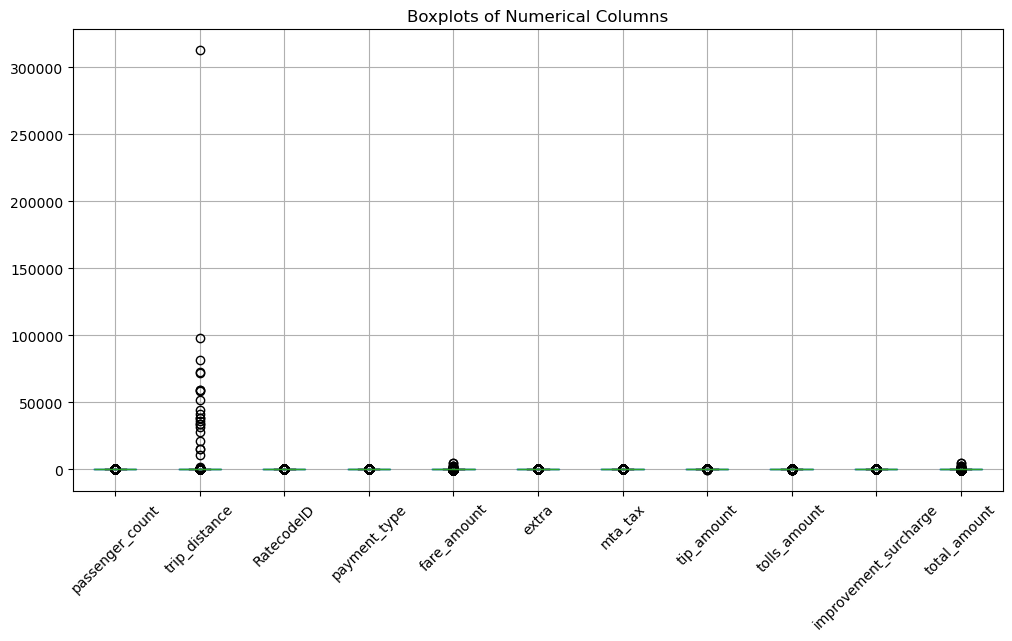

In [124]:
# Create the boxplot
df_taxiData[Numerical_cols].boxplot(figsize=(12, 6))

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45)

# Add a title
plt.title('Boxplots of Numerical Columns')

# Show the plot
plt.show()

In [132]:
Q1 = df_taxiData['trip_distance'].quantile(0.25)
Q3 = df_taxiData['trip_distance'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Outliers: below {lower_bound} or above {upper_bound}")



Outliers: below -2.165 or above 6.275


In [134]:
df_taxiData[df_taxiData['trip_distance'] > upper_bound] \
    .sort_values('trip_distance', ascending=False) \
    .head(50)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
2958079,2,2024-01-30 06:37:00,2024-01-30 06:50:00,0,312722.30,0,N,151,162,0,14.46,0.00,0.5,3.69,0.00,1.0,22.15,0.0,False
2934895,2,2024-01-25 08:39:00,2024-01-25 09:06:00,0,97793.92,0,N,4,13,0,29.71,0.00,0.5,3.30,0.00,0.3,36.31,0.0,False
2911232,2,2024-01-20 08:01:00,2024-01-20 08:26:00,0,82015.45,0,N,40,43,0,16.56,0.00,0.5,1.00,0.00,1.0,21.56,0.0,False
2920143,2,2024-01-21 11:58:00,2024-01-21 12:12:00,0,72975.97,0,N,209,211,0,12.70,0.00,0.5,3.34,0.00,1.0,20.04,0.0,False
2891991,2,2024-01-17 08:41:00,2024-01-17 09:23:00,0,71752.26,0,N,33,161,0,41.06,0.00,0.5,4.51,0.00,1.0,49.57,0.0,False
2843369,2,2024-01-05 15:46:00,2024-01-05 16:17:00,0,59282.45,0,N,74,47,0,32.02,0.00,0.5,0.00,0.00,1.0,33.52,0.0,False
2854947,2,2024-01-09 07:13:00,2024-01-09 07:17:00,0,59076.43,0,N,141,162,0,13.82,0.00,0.5,5.35,0.00,1.0,23.17,0.0,False
2931119,2,2024-01-24 12:26:00,2024-01-24 12:42:00,0,58298.51,0,N,151,236,0,12.94,0.00,0.5,1.69,0.00,1.0,18.63,0.0,False
2868605,2,2024-01-12 05:16:00,2024-01-12 05:26:00,0,51619.36,0,N,238,186,0,16.17,0.00,0.5,4.03,0.00,1.0,24.20,0.0,False
2869099,2,2024-01-12 07:18:00,2024-01-12 07:38:00,0,44018.64,0,N,233,138,0,32.75,0.00,0.5,8.74,6.94,1.0,52.43,0.0,False


In [136]:
outliers = df_taxiData[
    (df_taxiData['trip_distance'] < lower_bound) |
    (df_taxiData['trip_distance'] > upper_bound)
]

outliers[['trip_distance', 'fare_amount']].head(10)


,trip_distance,fare_amount
6,10.82,45.7
12,8.20,59.0
24,23.90,120.0
30,8.89,47.8
32,11.51,44.3
54,11.48,47.8
55,8.89,35.2
57,6.60,28.2
75,20.85,70.0
86,9.50,44.3


## Removing Unrealistic Trip Distances
To ensure the dataset reflects plausible taxi trips within New York City, we filter out trips with distances exceeding 100 miles, as these are likely data entry errors or outli


In [138]:
# Remove impossible trip distances (>100 miles is a safe cutoff for NYC taxis)
df_taxiData_clean = df_taxiData[df_taxiData['trip_distance'] <= 100]

# Quick check
print("Rows removed:", len(df_taxiData) - len(df_taxiData_clean))
print("New max trip_distance:", df_taxiData_clean['trip_distance'].max())

Rows removed: 56
New max trip_distance: 99.0


## Conclusion on Outlier Removal
Outliers with implausibly high trip distances were removed to ensure a realistic representation of New York City taxi trips. The cleaned dataset is now ready for feature engineering and further analysis.


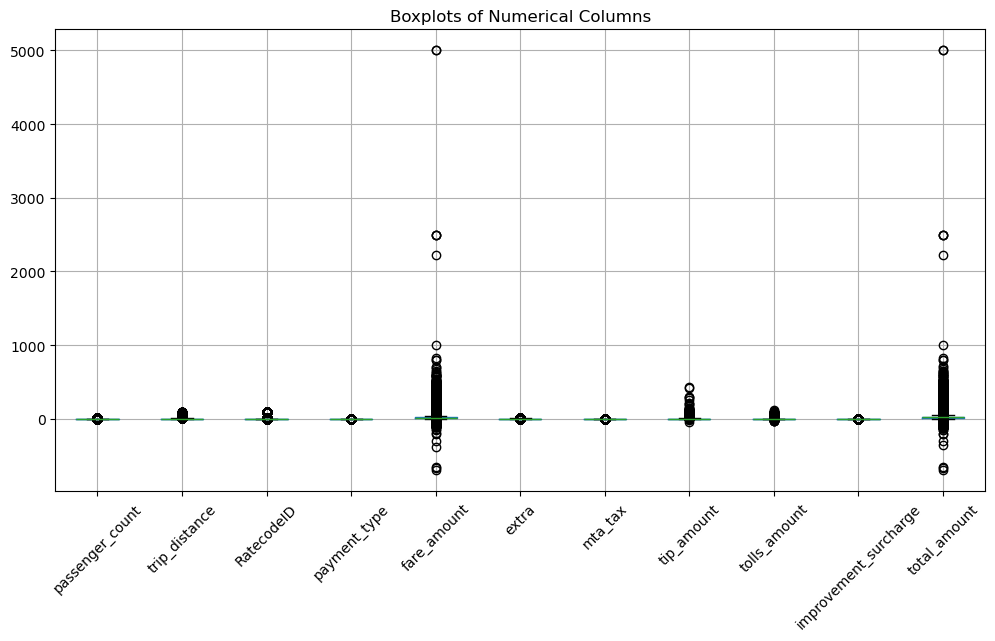

In [140]:
# Create the boxplot
df_taxiData_clean[Numerical_cols].boxplot(figsize=(12, 6))

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45)

# Add a title
plt.title('Boxplots of Numerical Columns')

# Show the plot
plt.show()

In [142]:
df_taxiData_clean.tail(10)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
2964614,2,2024-01-31 23:23:02,2024-01-31 23:37:53,0,2.50,0,N,50,137,0,17.09,0.00,0.5,3.16,0.00,1.0,24.25,0.0,False
2964615,1,2024-01-31 23:54:30,2024-02-01 00:01:05,0,1.20,0,N,114,231,0,8.60,1.00,0.5,2.72,0.00,1.0,16.32,0.0,False
2964616,2,2024-01-31 23:40:02,2024-01-31 23:47:45,0,1.89,0,N,48,68,0,12.54,0.00,0.5,3.31,0.00,1.0,19.85,0.0,False
2964617,2,2024-01-31 23:27:00,2024-01-31 23:43:00,0,8.99,0,N,50,127,0,35.24,0.00,0.5,7.85,0.00,1.0,47.09,0.0,False
2964618,1,2024-01-31 23:18:48,2024-01-31 23:38:05,0,3.90,0,N,90,238,0,21.90,1.00,0.5,4.03,0.00,1.0,30.93,0.0,False
2964619,2,2024-01-31 23:45:59,2024-01-31 23:54:36,0,3.18,0,N,107,263,0,15.77,0.00,0.5,2.00,0.00,1.0,21.77,0.0,False
2964620,1,2024-01-31 23:13:07,2024-01-31 23:27:52,0,4.00,0,N,114,236,0,18.40,1.00,0.5,2.34,0.00,1.0,25.74,0.0,False
2964621,2,2024-01-31 23:19:00,2024-01-31 23:38:00,0,3.33,0,N,211,25,0,19.97,0.00,0.5,0.00,0.00,1.0,23.97,0.0,False
2964622,2,2024-01-31 23:07:23,2024-01-31 23:25:14,0,3.06,0,N,107,13,0,23.88,0.00,0.5,5.58,0.00,1.0,33.46,0.0,False
2964623,1,2024-01-31 23:58:25,2024-02-01 00:13:30,0,8.10,0,N,138,75,0,32.40,7.75,0.5,7.29,6.94,1.0,55.88,0.0,False


In [144]:
df_taxiData_clean.shape

(2933460, 19)

## Feature Preparation (Handled in SQL)
Feature engineering such as temporal segmentation (weekday/weekend, hour of day) and analytical aggregations are intentionally handled in SQL to maintain a single source of truth and ensure consistency across downstream analyses and dashboards.

In this Python workflow, the focus is on data cleaning, validation, and preparation to support SQL-based transformations.


In [146]:
# Validate Key Analytical Columns
df_taxiData_clean[['fare_amount', 'trip_distance', 'total_amount']].describe()


,fare_amount,trip_distance,total_amount
count,2.933460e+06,2.933460e+06,2.933460e+06
mean,1.857566e+01,3.228048e+00,2.734799e+01
std,1.832487e+01,4.356603e+00,2.261436e+01
min,-7.000000e+02,0.000000e+00,-6.957500e+02
25%,8.600000e+00,1.000000e+00,1.548000e+01
50%,1.280000e+01,1.680000e+00,2.016000e+01
75%,2.050000e+01,3.110000e+00,2.870000e+01
max,5.000000e+03,9.900000e+01,5.000000e+03


In [154]:
df_taxiData_clean['payment_type'].value_counts()




payment_type
1    2318994
2     431855
0     140140
4      27974
3      14497
Name: count, dtype: int64

In [156]:
df_taxiData_clean['VendorID'].value_counts()

VendorID
2    2203473
1     729727
6        260
Name: count, dtype: int64

In [158]:
df_taxiData_clean['RatecodeID'].value_counts()

RatecodeID
1     2635195
0      140140
2       96914
99      28661
5       18755
3        7653
4        6137
6           5
Name: count, dtype: int64

## Summary and Next Steps
This notebook focused on data cleaning, validation, and preparation of NYC Yellow Taxi trip data.  
The cleaned dataset is used as input for SQL-based feature engineering and Power BI dashboards to analyze revenue trends, trip behavior, and vendor performance.


In [215]:
#T change dataset ito CSV for SQL QUERIES
df_taxiData_clean.to_csv(
    "nyc_taxi_clean.csv",
    index=False
)
